In [2]:
#Question 1: Read the Bike Details dataset into a Pandas DataFrame and display its
#first 10 rows.


import pandas as pd

# Load the dataset
bike_df = pd.read_csv("BIKE DETAILS.csv")

# Display first 10 rows
print(bike_df.head(10))

# Show shape and column names
print("\nShape of DataFrame:", bike_df.shape)
print("Column Names:", bike_df.columns.tolist())


                                   name  selling_price  year seller_type  \
0             Royal Enfield Classic 350         175000  2019  Individual   
1                             Honda Dio          45000  2017  Individual   
2   Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3     Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                 Yamaha SZ [2013-2014]          20000  2011  Individual   
5                      Honda CB Twister          18000  2010  Individual   
6                  Honda CB Hornet 160R          78500  2018  Individual   
7  Royal Enfield Bullet 350 [2007-2011]         180000  2008  Individual   
8                Hero Honda CBZ extreme          30000  2010  Individual   
9                    Bajaj Discover 125          50000  2016  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000     

In [3]:
#Question 2: Check for missing values in all columns and describe your approach for
#handling them.

# Check missing values
missing_values = bike_df.isnull().sum()
print(missing_values)


name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64


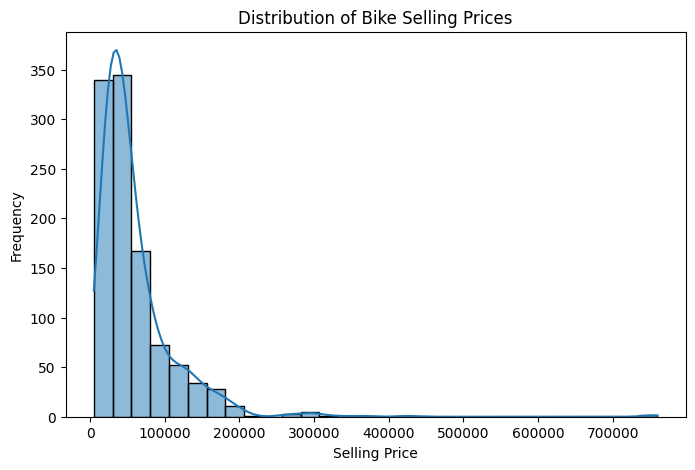

In [4]:
#Question 3: Plot the distribution of selling prices using a histogram and describe the
#overall trend.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(bike_df['selling_price'], bins=30, kde=True)
plt.title("Distribution of Bike Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()


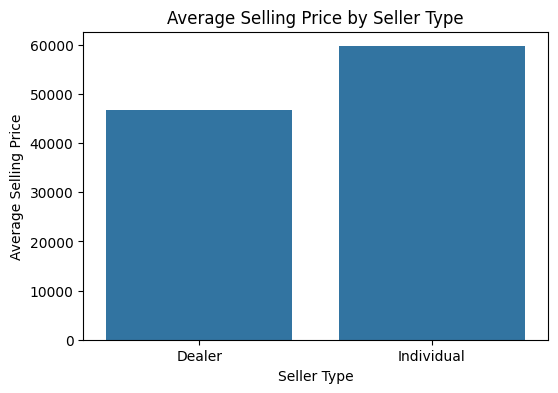

,selling_price
seller_type,
Dealer,46666.666667
Individual,59711.923223


In [5]:
#Question 4: Create a bar plot to visualize the average selling price for each seller_type
#and write one observation.

avg_price = bike_df.groupby('seller_type')['selling_price'].mean()

plt.figure(figsize=(6,4))
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title("Average Selling Price by Seller Type")
plt.ylabel("Average Selling Price")
plt.xlabel("Seller Type")
plt.show()

avg_price


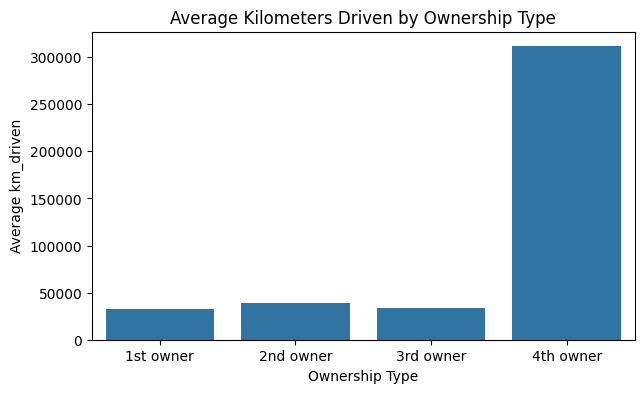

,km_driven
owner,
1st owner,32816.583333
2nd owner,39288.991870
3rd owner,33292.181818
4th owner,311500.000000


In [6]:
#Question 5: Compute the average km_driven for each ownership type (1st owner,
#2nd owner, etc.), and present the result as a bar plot.

avg_km = bike_df.groupby('owner')['km_driven'].mean()

plt.figure(figsize=(7,4))
sns.barplot(x=avg_km.index, y=avg_km.values)
plt.title("Average Kilometers Driven by Ownership Type")
plt.ylabel("Average km_driven")
plt.xlabel("Ownership Type")
plt.show()

avg_km


In [7]:
#Question 6: Use the IQR method to detect and remove outliers from the km_driven
#column. Show before-and-after summary statistics.

Q1 = bike_df['km_driven'].quantile(0.25)
Q3 = bike_df['km_driven'].quantile(0.75)
IQR = Q3 - Q1

# Define limits
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Before and after
print("Before:", bike_df['km_driven'].describe())

bike_df = bike_df[(bike_df['km_driven'] >= lower) & (bike_df['km_driven'] <= upper)]

print("\nAfter:", bike_df['km_driven'].describe())


Before: count      1061.000000
mean      34359.833176
std       51623.152702
min         350.000000
25%       13500.000000
50%       25000.000000
75%       43000.000000
max      880000.000000
Name: km_driven, dtype: float64

After: count     1022.000000
mean     28203.415851
std      19552.083583
min        350.000000
25%      13000.000000
50%      24000.000000
75%      40000.000000
max      86000.000000
Name: km_driven, dtype: float64


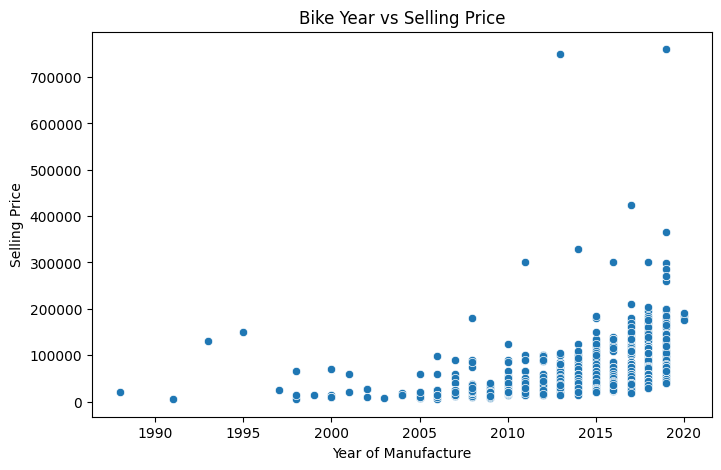

In [8]:
#Question 7: Create a scatter plot of year vs. selling_price to explore the
#relationship between a bike's age and its price.

plt.figure(figsize=(8,5))
sns.scatterplot(x='year', y='selling_price', data=bike_df)
plt.title("Bike Year vs Selling Price")
plt.xlabel("Year of Manufacture")
plt.ylabel("Selling Price")
plt.show()


In [9]:
#Question 8: Convert the seller_type column into numeric format using one-hot
#encoding. Display the first 5 rows of the resulting DataFrame.

encoded_df = pd.get_dummies(bike_df, columns=['seller_type'], drop_first=True)
print(encoded_df.head())


                                  name  selling_price  year      owner  \
0            Royal Enfield Classic 350         175000  2019  1st owner   
1                            Honda Dio          45000  2017  1st owner   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  1st owner   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  1st owner   
4                Yamaha SZ [2013-2014]          20000  2011  2nd owner   

   km_driven  ex_showroom_price  seller_type_Individual  
0        350                NaN                    True  
1       5650                NaN                    True  
2      12000           148114.0                    True  
3      23000            89643.0                    True  
4      21000                NaN                    True  


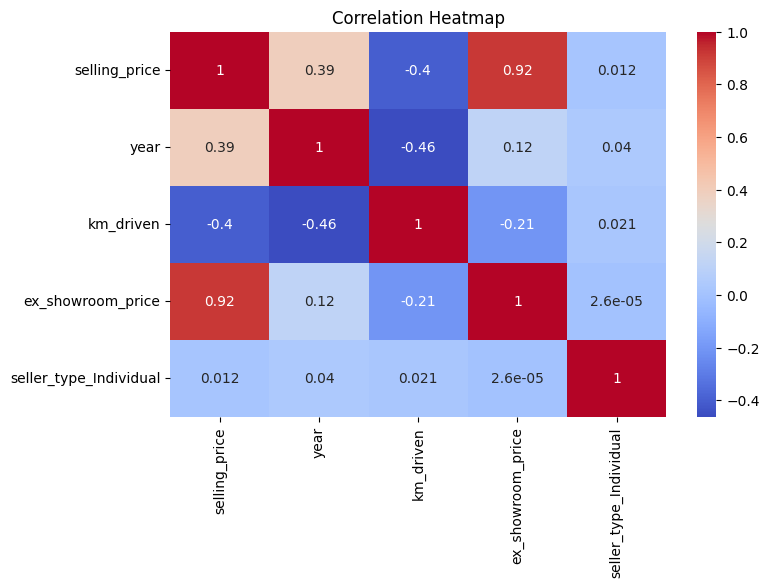

In [11]:
#Question 9: Generate a heatmap of the correlation matrix for all numeric columns.
#What correlations stand out the most?

# Select only numeric columns for correlation calculation
numeric_df = encoded_df.select_dtypes(include=['number', 'bool'])

plt.figure(figsize=(8,5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Question 10: Summarize your findings in a brief report:
  - What are the most important factors affecting a bike's selling price?
  - Mention any data cleaning or feature engineering you performed.


    - Important Factors Affecting Price:
    - Year (Age) – newer bikes have higher resale prices.
    - Ex-showroom Price – higher original price → higher resale.
    - Owner Type – 1st owner bikes fetch more.
    - Seller Type – dealers sell at higher prices.
    - Km Driven – more usage reduces value.
  - Data Cleaning & Feature Engineering:
    - Filled missing values in ex_showroom_price with median.
    - Removed outliers in km_driven via IQR method.
    - Converted seller_type to numeric using one-hot encoding.
    - Verified distributions and correlations for model readiness.